In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from functions.funcs import *
import functions.output_functions as output 
import functions.plotting as plot
import geopandas as gpd
import matplotlib.gridspec as gridspec
import seaborn as sns
import shapely as shp


from importlib import reload 
reload(output)

<module 'functions.output_functions' from 'C:\\FATE\\Code\\functions\\output_functions.py'>

## Analyizing Forcasts for: CMEMS, Kriging, and percistance

In [29]:

data= {
      # 'No Forecast':     ['No_forecast', 'forestgreen'],
      # 'Climatology':      ['climatological2024', 'dodgerblue'],
      'Persistence':      ['combined_Percistance2024', 'blueviolet'],
      # 'All Methods':      ['Final/' + 'Initial_angle_v1_2026', 'k'],
      'GLORYs':             ['Final/' + 'CMEMS_2026', 'orange'],
      # 'GLORYs+bias' :       ['Final/cmems_bias_meanremoved_2026', 'red'],
      'GLORYs+bias+Persistence' : ['Final/cmems_bias_pers_meanremoved_2026', 'black'],
      # 'GLORYs+bias+wind' :       ['cmems_bias_wind_meanremoved_2026', 'green'],
      # 'GLORYs+wind_meanstillon':        ['Final/' + 'cmems_wind_2026', 'olive'], 
      #'GLORYs+wind+pers':   ['Final/'+'CMEMS_wind_pers_2026', 'green'], 
      # 'OSCAR':            ['Final/'+'OSCAR_2026', 'blue'],
      # 'OSCAR+Wind':       ['OSCAR_2022_2025_wind', 'mediumpurple'],
      #'OSCAR+Wind+Pers':  ['Final/'+'OSCAR_wind_pers_2026', 'indigo'],
      #'Initial_speed_dif':    ['Initial_angle_No_pers_2026', 'k']
}

# Access all colors
colors = [v[1] for v in data.values()]

dslist  = []
for key, item in data.items(): 
  ds = pd.read_csv('saved_output/'+item[0]+'.csv')
  dslist.append(ds)

## fix persistance 
if 'Persistence' in data.keys():
  pers_idx = list(data.keys()).index('Persistence')
  persistance = dslist[pers_idx]
  persistance = persistance.drop(columns= ["BouyID", 'speed_ms_persistence'])

  # to fix persistance column names intial
  persistance=persistance.rename(columns={"Latitude_true" : "lat_true", "Longitude_true": "lon_true", 
                    "Latitude_persistence": "lat_forcast",
                      "Longitude_persistence": "lon_forcast", 
                      "lead_time_hours": "leadtime" , "DateTime": "Time"})
  dslist[pers_idx] = persistance

In [30]:
bins = np.linspace(0,8*24,2*24+1)
skill_score = False ## False: does not interpolate 
recalc_skill_score = False #(True: takes a 5-10 minutes to run)
#Outputs to be plotted
ltes = []
stds = []
stds_low = []
sss = []
dslist_notinterp = []

for i, dsi in enumerate(dslist):
    dsi = output.add_starttime(dsi)
    dsi['error_km'] = output.haversine_df(dsi, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
    dsi["lead_bins"] = pd.cut(dsi["leadtime"], bins, right= True)
    dslist_notinterp.append(dsi) 

    ltei = dsi.groupby("lead_bins", observed=False).apply(output.calculate_rmse, include_groups=False).to_numpy()
    pad = np.array([0])
    ltei  = np.concat([pad, ltei])
    ltes.append(ltei)
    
    stdi = dsi.groupby("lead_bins", observed=False)["error_km"].quantile(0.9)
    stdi = np.concat([pad, stdi])
    stds.append(stdi)
    stdi_low = dsi.groupby("lead_bins", observed=False)["error_km"].quantile(0.3)
    stdi_low = np.concat([pad, stdi_low])
    stds_low.append(stdi_low)

    if recalc_skill_score == True: 
        ##Interpolates Data onto regular intervals
        dsi = output.add_starttime(dsi)
        dsi = dsi.groupby(['BuoyID','starttime'], observed= False).apply(output.interpolate_data, include_groups = False).reset_index(level=['BuoyID', 'starttime']).reset_index(drop=True)
        dsi = dsi.groupby(['BuoyID','starttime'], observed= False).apply(output.dtrue, include_groups = False).reset_index(level=['BuoyID', 'starttime']).reset_index(drop=True)
        dsi['dlat_true_km'] = dsi['dlat_true']*110
        dsi['dlon_true_km'] =dsi['dlon_true']*110
        dsi["lead_bins"] = pd.cut(dsi["leadtime"], bins, right= True)
        # Calc Error_km and RMSE of displacement 
        dsi['error_km'] = output.haversine_df(dsi, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
        dsi["lead_bins"] = pd.cut(dsi["leadtime"], bins, right= True)

        g = dsi.groupby(['BuoyID', 'starttime'], observed=False)
        # cumsumdistance: d is row-wise, dcum is cumsum of d per group
        dsi['d']    = (dsi['dlat_true_km']**2 + dsi['dlon_true_km']**2)**(1/2)
        dsi['dcum'] = g['d'].transform('cumsum')
        # cumsumerror: cumsum of error_km per group
        dsi['error_cum'] = g['error_km'].transform('cumsum')
        # skillscore
        dsi['skillscore'] = 1- (dsi['error_km'] / dsi['dcum'])
        dsi['skillscore'] = dsi['skillscore'].clip(lower = 0)

        ss = dsi.groupby("lead_bins", observed=False)['skillscore'].mean().to_numpy()
        pad = np.array([0])
        ss  = np.concat([pad, ss])
        sss.append(ss)
        dslist[i] = dsi
        # saving so doesnt have to recalulate
if recalc_skill_score == True: 
    sss_df = pd.DataFrame(np.stack(sss).T, index=bins, columns=list(data.keys()))

    sss_df.index.name = 'leadtime_hrs'


    sss_df.to_csv('saved_output/skill_scores.csv')   
    print("Saved skill scores to saved_output/skill_scores.csv")

In [31]:
## Load saved skill scores (avoids re-running the 5-10 min interpolation)
sss_df = pd.read_csv('saved_output/skill_scores.csv', index_col='leadtime_hrs')
sss = [sss_df[col].to_numpy() for col in sss_df.columns]

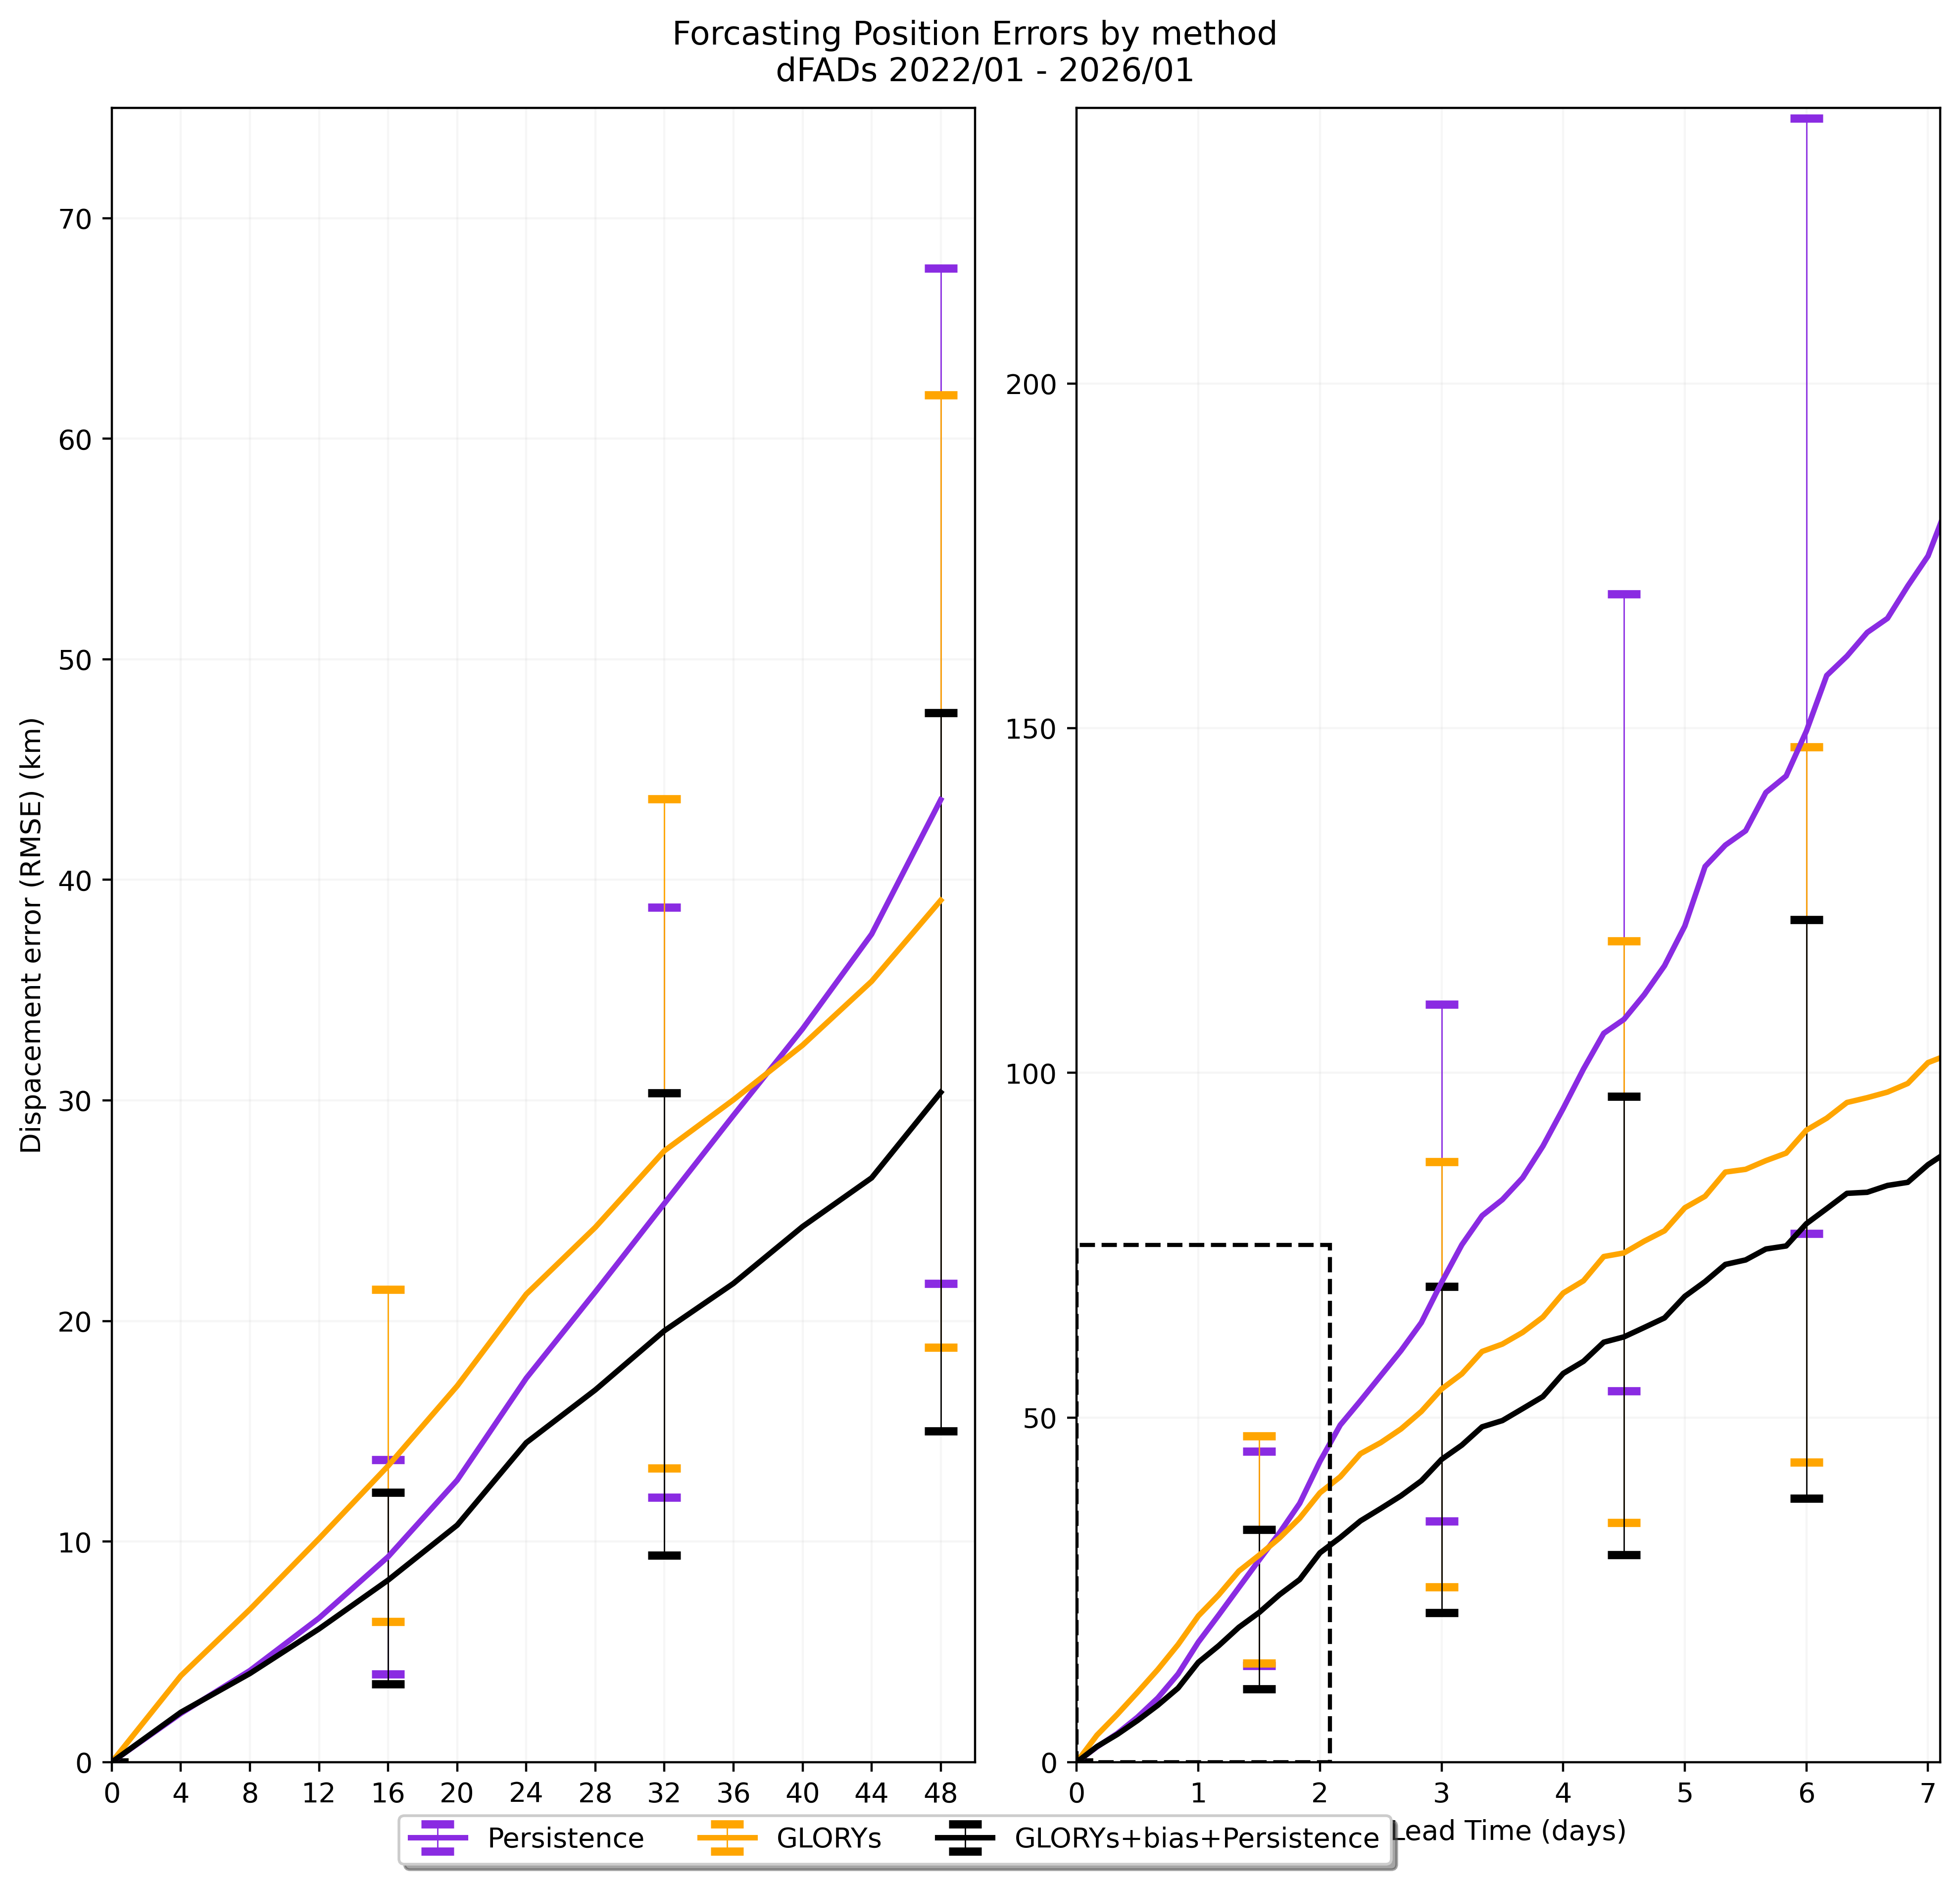

In [32]:
errorbars = True
fig = plt.figure(figsize=(10,10), dpi = 400)
gs = gridspec.GridSpec(3, 2, width_ratios=[3,3], height_ratios= [5,5,3])
labels = list(data.keys())
bins = np.linspace(0,8*24,2*24+1)
if skill_score == True: 
    ax0 = fig.add_subplot(gs[:2,0])
    ax1 = fig.add_subplot(gs[:2,1])
    ax2 = fig.add_subplot(gs[2,:])
    #ax3 = fig.add_subplot(gs[2,1])
else:     
    ax0 = fig.add_subplot(gs[:,0])
    ax1 = fig.add_subplot(gs[:,1])

for i in range(len(dslist)):
    # asymmetric error bars: 30th quantile below, 70th quantile above RMSE
    yerr0 = [np.maximum(ltes[i][:13] - stds_low[i][:13], 0), np.maximum(stds[i][:13] - ltes[i][:13], 0)]
    yerr1 = [np.maximum(ltes[i][:] - stds_low[i][:], 0), np.maximum(stds[i][:] - ltes[i][:], 0)]
    alpha = 1
    ls = '-'
    if labels[i] in ['No Forecast', 'Climatology']:
        yerr0 = None
        yerr1 =  None
        alpha = 0.5
        ls = '--'
    if errorbars: 
        ax0.errorbar(bins[0:13], ltes[i][:13], lw = 2, yerr = yerr0, color = colors[i],
                    capsize = 6  , errorevery=4, elinewidth= 0.5, mew = 3, alpha = alpha, ls = ls)
        ax1.errorbar(bins[:]/24, ltes[i][:], lw =2, yerr = yerr1 , label = labels[i],  color =  colors[i],
                    capsize = 6  , errorevery=9, elinewidth= 0.5, mew = 3, alpha =  alpha, ls = ls)
    if not errorbars: 
        ax0.plot(bins[0:13], ltes[i][:13], lw = 2,  color = colors[i], alpha = alpha, ls = ls)
        ax1.plot(bins[:]/24, ltes[i][:], lw = 2,  color = colors[i], alpha = alpha, ls = ls)

    if skill_score == True: 
        ax2.plot(sss_df.index / 24, sss_df.iloc[:, i], color=colors[i], lw=2)

#limits
ax0.set_xticks(np.linspace(0,52,14))
ax0.set_xlim(0,50)
ax0.set_ylim(0,75)
#ax0.set_ylim(0,150)
ax1.set_xlim(0,7.1)
ax1.set_ylim(0,240)
ax1.set_xticks(np.linspace(0,7,8))

ax0.set_ylabel("Dispacement error (RMSE) (km)")
ax0.set_xlabel("Lead Time (hrs)")
ax1.set_xlabel("Lead Time (days)")
ax0.grid(alpha = 0.1)
ax1.grid(alpha = 0.1)

# Draw on ax1 the same data-window shown in ax0 (ax0 x is hours, ax1 x is days)
x0_hr, x1_hr = ax0.get_xlim()
y0, y1 = ax0.get_ylim()

zoom_box = plt.Rectangle((x0_hr / 24.0, y0), (x1_hr - x0_hr) / 24.0, y1 - y0,
                         fill=False, edgecolor="black", linestyle="--", linewidth=1.5, zorder=10)
ax1.add_patch(zoom_box)
if skill_score == True:
    ax2.set(xlim = [0,7.15],ylim = [-0.1,1], ylabel = 'Skill Score', xlabel ='days')
    ax2.grid(alpha = 0.1)

fig.legend(loc='upper center', bbox_to_anchor=(3.2/7, 0.08),
          fancybox=True, shadow=True, ncol=3)
fig.suptitle("Forcasting Position Errors by method \n dFADs 2022/01 - 2026/01")
fig.set_facecolor("#FFFFFF")
fig.tight_layout()
plt.subplots_adjust(bottom=0.1)
#fig.savefig(r"..\..\Figures\Paper\FIG3.pdf")


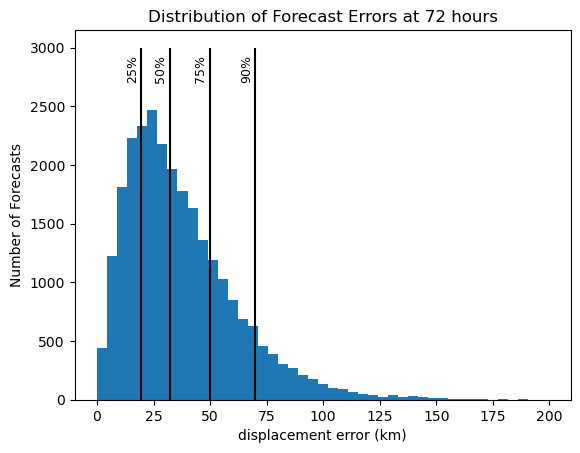

In [28]:
## making simple plot of displacement errors

ds = dslist[-1]
ds = ds[(ds.leadtime >70 ) & (ds.leadtime < 74 )].copy()
ds['error_km'] = output.haversine_df(ds, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fig, ax = plt.subplots()
ax.hist(ds.error_km, bins = 45)
ax.set(xlabel = 'displacement error (km)', ylabel = 'Number of Forecasts', title = 'Distribution of Forecast Errors at 72 hours')
for i in [0.25, 0.5, 0.75, 0.9]:
    a = ds.error_km.quantile(i)
    ax.vlines(a, 0, 3000, color='k')
    ax.text(a-4, 2700, f"{int(i*100)}%", ha='center', va='bottom', fontsize=9, rotation='vertical')

In [7]:
## calcuates matrix table showing improvement compaired to other model 
target_lt  = 24*6 # in incruments of 4 hours 
def compair_methods_table(target_hour: int, ltes:list, data:dict, over_entire_period = True):
    idx = np.where(bins == target_hour)[0][0]
    ltes = np.stack(ltes)
    keys = list(data.keys())
    rows = []
    for i, key_i in enumerate(keys): 
        if over_entire_period == False: 
            a = ltes[i][idx]
            compair = [(a - ltes[j][idx]) / a for j in range(len(data))]
        else:
            a = ltes[i][1:idx+1]   # skip index 0 (zero pad) to avoid div-by-zero
            compair = [np.mean((a - ltes[j][1:idx+1]) / a) for j in range(len(data))]
        rows.append(pd.Series(compair, index=keys, name=key_i))
    table = pd.DataFrame(rows)
    return table
table  = compair_methods_table(24, ltes, data)
print(f"24 hours: \n {table}") ## column is x% better than the row index 
table2  = compair_methods_table(24*7, ltes, data)
print(f"7 days: \n {table2}") ## column is x% better than the row index 


24 hours: 
                          No Forecast  Climatology  Persistence    GLORYs  \
No Forecast                 0.000000     0.195532     0.573422  0.369515   
Climatology                -0.243372     0.000000     0.468859  0.216383   
Persistence                -1.371052    -0.910158     0.000000 -0.498233   
GLORYs                     -0.587123    -0.276286     0.321516  0.000000   
GLORYs+bias                -0.640071    -0.318906     0.298890 -0.033419   
GLORYs+bias+Persistence    -1.593226    -1.086759    -0.101851 -0.635611   

                         GLORYs+bias  GLORYs+bias+Persistence  
No Forecast                 0.389931                 0.613660  
Climatology                 0.241733                 0.519491  
Persistence                -0.449633                 0.087423  
GLORYs                      0.032326                 0.386592  
GLORYs+bias                 0.000000                 0.366086  
GLORYs+bias+Persistence    -0.582739                 0.000000  
7 days:

In [8]:
## calculating Distributution of errors. 
bins_middle = (bins[:-1] + bins[1:])/2
#bins_middle = bins_middle[bins_middle < 168]
quantiles = np.linspace(0.1,1, 10)
leadbins = ds.lead_bins.unique().sort_values()

df = pd.DataFrame({'lead_bins':leadbins})

q =0.5
for q in quantiles:
    q_list = dslist[0].groupby('lead_bins', observed= False)['error_km'].quantile(q)
    q_list = q_list.to_frame().rename(columns = {'error_km':round(q,1)}).reset_index()
    df = df.merge(q_list)
df= df.round(3)
df['leadtime'] = np.array(bins_middle[:], dtype = int)
dff = df.set_index('leadtime').drop(columns = 'lead_bins')
#dff.to_csv(r"..\Data\errors_quantile_leadtimes.csv")


In [10]:
#Skill score analysis
if skill_score: 
    df = dslist[0].copy()
    # First look at skill score at a throughout a certain time 

    #looking at skill scores at 3 days forecasts. 
    leadbins = df.lead_bins.unique().sort_values()
    tbin = leadbins[3*6]
    print(tbin)
    dfh  =df.groupby('lead_bins', observed = False).get_group(tbin).copy()
    dfh['startday'] = dfh.starttime.dt.date
    dailyss = dfh.groupby('startday', observed = False)['skillscore'].mean().reset_index(level = 'startday')
    dailyss['skill30day'] = dailyss['skillscore'].rolling(30, 1, center = False).mean()
    fig , ax = plt.subplots()
    ax.plot(dailyss.startday , dailyss.skillscore)
    ax.plot(dailyss.startday , dailyss.skill30day)

(72.0, 76.0]


KeyError: 'Column not found: skillscore'

### Combining Drifter and dFAD data. 



### Corrilation between errors

In [13]:
### Plotting indivigual trajectories. 


ds =  output.add_starttime(ds)
ds2 =  output.add_starttime(ds2)
ds3 =  output.add_starttime(ds3)
ds4 =  output.add_starttime(ds4)
ds5 =  output.add_starttime(ds5)


## Plotting indivigual tracks

In [14]:
def drifter_forecast_plot(individual_csv, true_data,   datetime_column='DateTime'):
    df = individual_csv
    commid = df['BuoyID'].unique()
    df = df.rename(columns = {"Time": "DateTime"})
    true_data = true_data.rename(columns = {"Time": "DateTime"})
    df=df.sort_values('DateTime')
    true_data=true_data.sort_values('DateTime')
    #true_data = pd.read_csv(f'../individual_commID_data/cleaned_data_inconsistent_removed/new/cleaned_new_approach{commid}.csv')
 
    # Palmyra Atoll GPS coordinates
    pa_lat = 5.8900
    pa_lon = 197.9200- 360# adjusted by adding 360
 
    df.loc[:, datetime_column] = pd.to_datetime(df[datetime_column])
    true_data.loc[:, datetime_column] = pd.to_datetime(true_data[datetime_column])
    # Filter by week
    start_date = df[datetime_column].min()
    end_date = df[datetime_column].max()
 
    # Only get time of forecast
    timed_data = true_data[(true_data['DateTime'] >= start_date) & (true_data['DateTime']<=end_date)]
 
    #first_week_data = df[(df[datetime_column] >= start_date) & (df[datetime_column]<end_date)]
    timed_data  = timed_data.sort_values("DateTime")

 
    plt.figure(figsize=(20,10))
    plt.plot(pa_lon, pa_lat, 'ro', markersize=8, label='Palmyra Atoll')
    plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center right')
 
 
    plt.scatter(
        df['lon_forcast'],
        df['lat_forcast'],
        # hue=datetime_column,
        # palette='viridis',
        label='Forecasted Trajectory'
    )
    plt.plot(
        timed_data['lon_true'],
        timed_data['lat_true'],
        color='black',
        label='True Trajectory'
    )
    
    plt.annotate(
        f'Start Date: {start_date}',
        xy=(0.02, 0.98),
        xycoords='axes fraction',
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round, pad=0.2', fc='white', ec='black', lw=1, alpha=0.7)
    )
 
    plt.annotate(
        f'End Date: {end_date}',
        xy=(0.98, 0.98),
        xycoords='axes fraction',
        ha='right',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round, pad=0.2', fc='white', ec='black', lw=1, alpha=0.7)
    )
    
 
    plt.title(f'Scatter Plot of Latitude vs. Longitude of CommId: {commid} Forecast vs True')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    #plt.savefig(f'../forecast_plots/comparison_plots/comparison_commID_{commid}_forecast_vs_true.png')

In [15]:
dFADs = gpd.read_parquet(r"..\Data\Mappedwinds_OSCAR_SAT_MI_Cleanedspeeds.parquet") 
def True_dFAD_data(ds, buoyID):
    """Turns one dFAD into a DataFrame"""
    Truedata = ds.query("BuoyName == @buoyID").reset_index(drop = True)
    x,y= Truedata.at[0,"geometry"].xy
    time = Truedata.at[0,"TimeStamp"]
    Truedata = pd.DataFrame({"DateTime":time, "lat_true": y, "lon_true": x})
    Truedata.DateTime = pd.to_datetime(Truedata.DateTime)
    return Truedata

def Add_bathymetry(fig,ax,cbar = True):
    from matplotlib import colormaps 
    bath = xr.open_dataset(r"..\Data\bath.nc")
    #bath_cmap = cm.get_cmap("Blues_r").copy()
    bath_cmap = colormaps['Blues_r']
    bath_cmap.set_over('green')
    negative_levels = np.linspace(-10000, 0, 11)
    cbr = ax.contourf( bath["lon"], bath["lat"], bath["elevation"], 
                     cmap = bath_cmap, alpha = 0.8, levels = negative_levels, extend = "max")
    if cbar == True:
        fig.colorbar(cbr)
    cbr.set_label("m/s")
    return fig, ax

def plot_collectionzone(ax): 
    import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def plot_circle_km(ax, radius_km=5, **patch_kwargs):
    from matplotlib.patches import Circle
    point = Palmyra_obj()
    circle = Circle(
        (point.x, point.y),
        radius_km,
        fill=False, 
        alpha = 0.75,
        **patch_kwargs
    )
    ax.add_patch(circle)
    return ax

def set_palmyra_lims(ax):
    ax.set_xlim(-163.6, -160.7)
    ax.set_ylim(4.5,7.7)
    return ax

2687


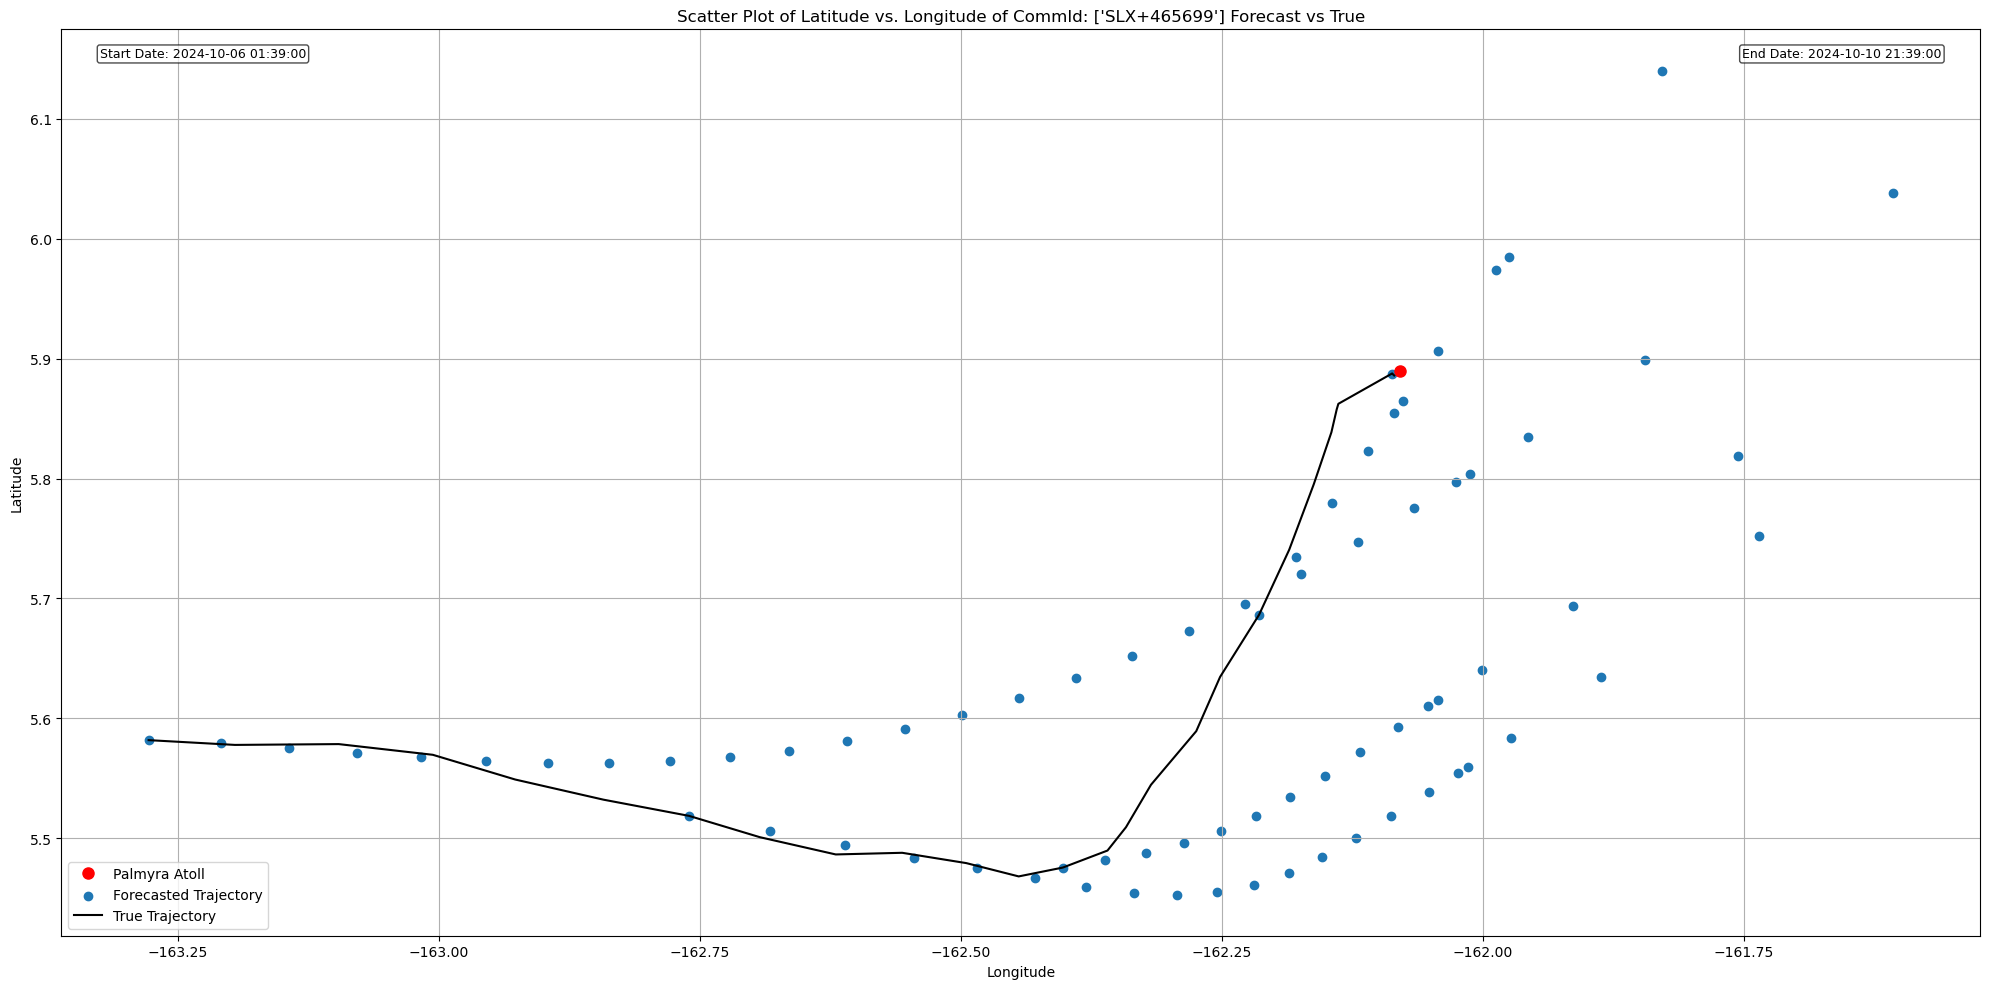

In [16]:
IDs = ds.BuoyID.unique()
print(len(IDs))
buoyID ="SLX+465699"

Truedata = True_dFAD_data(dFADs, buoyID)

perplot = ds.query("BuoyID == @buoyID ") ##SLX+487116 #10 had loops ##16 weird points ##119 ##hit palyra SLX+463917
#truedata = perplot.query("leadtime == 0 ")
drifter_forecast_plot(perplot, true_data=Truedata, datetime_column="DateTime")

## Drawing Forecast cones and Animations. 
1) First have to merge the True dFAD dataset with the forecasted dataset. 
2) Draw forecast comes 

In [81]:
from functions import funcs
from functions.output_functions import merge_forecast_true, calc_intial_speed_dif, calc_iniial_lat
## Merging the true dFAD data onto forecasts 
longlist = generate_longlist(dFADs)

merged = merge_forecast_true(dslist_notinterp[0], longlist)
merged["speed"] = np.sqrt(merged.x_speed**2 + merged.y_speed**2)
merged["starttime"] = (merged.Time - pd.to_timedelta(merged.leadtime, "hours")).dt.round('min')
merged = merged.sort_values(['starttime', 'Time']).reset_index(drop = True)

merged_oscar = merged.query('best_model == "OSCAR"')
merged_cmems = merged.query('best_model == "cmems"')
merged_oscar = calc_intial_speed_dif(merged_oscar, "_OSCAR")
merged_cmems= calc_intial_speed_dif(merged_cmems)
merged_oscar = merged_oscar.rename(columns = {"initial_speed_dif_mag_OSCAR" : "initial_speed_dif_mag"})
merged = pd.concat([merged_oscar, merged_cmems])
merged = merged.sort_values(['BuoyID', 'starttime', 'Time']).reset_index(drop = True)

merged = calc_iniial_lat(merged)
merged = merged.sort_values(['BuoyID', 'starttime', 'Time']).reset_index(drop = True)

C:\FATE\Code\functions\output_functions.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged[speed_dif_mag] = np.sqrt((merged.x_speed - merged[u])**2 + (merged.y_speed - merged[v])**2)
C:\FATE\Code\functions\output_functions.py:110: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged[initial_speed_dif_mag] = merged.groupby(["BuoyID", "starttime"],  observed=False)[speed_dif_mag].transform("first")
C:\FATE\Code\functions\output_functions.py:109: SettingWithCopyWarning: 
A value is trying to be set o

In [35]:
def draw_forecast_cone(treudata, Forecast, q, ax): 
    """True data is all the true data within the window that is going to be plotted 
    Forecast is the one particle forecast 
    q is dataframe of uncurtainities to be plotted with collumns"""
    ## methos is to use a shapely object and then plot that. 
    ## start by making a circle at the last point
    Forecast = Forecast.sort_values("leadtime").reset_index(drop = True)
    q70 = q.sel(q = 0.7, method = 'nearest')
    qdf = pd.DataFrame({'qsolved':q70.qsolved,'leadtime' : q70.leadtime})
    ## now do this for all previous points and take the outside
    circles = []
    for n in range(len(Forecast)):
        poi = sp.Point( Forecast.iloc[n]['lon_forcast'], Forecast.iloc[n]['lat_forcast'])
        time = Forecast.iloc[n]['leadtime']
        maxid = np.abs((qdf.leadtime - time)).idxmin()
        r = qdf.qsolved[maxid]
        circle = poi.buffer(r/111)
        circles.append(circle)

    poly = sp.union_all(circles)
    if poly.geom_type == "MultiPolygon":
        for p in poly.geoms:
            x,y = p.exterior.xy
            ax.plot(x,y, color = "r")
            ax.fill(x,y, color = 'r', alpha= 0.1, zorder = 100)
            ax.set_clip_path
    else:
        x,y = poly.exterior.xy
        ax.plot(x,y, color = "r")
        ax.fill(x,y, color = 'r', alpha= 0.1, zorder = 100)
    return ax


from shapely.geometry import LineString, Point
from matplotlib.path import Path
def draw_forecast_cone_dynamic(truedata, Forecast, q, ax, res=200, cmap=plt.cm.YlOrRd, contours=True):
    Forecast = Forecast.sort_values("leadtime").reset_index(drop=True)
    
    Forecastlast = Forecast.tail(1).reset_index(drop = True) 

    # build shapely circles and union (your existing logic)
    circles = []
    for n in range(len(Forecast)):
        poi = Point(Forecast.iloc[n]['lon_forcast'], Forecast.iloc[n]['lat_forcast'])
        time = Forecast.iloc[n]['leadtime']
        r = q.sel(leadtime = time, q = 0.9, method = 'nearest').qsolved.values ## could draw other circles too or maybe still draw cone and just do shading 
        circles.append(poi.buffer(r / 111.0))
    poly = sp.union_all(circles)

    # bounds for the raster
    minx, miny, maxx, maxy = poly.bounds
    xs = np.linspace(minx, maxx, res)
    ys = np.linspace(miny, maxy, res)
    xv, yv = np.meshgrid(xs, ys)
    pts = np.column_stack([xv.ravel(), yv.ravel()])

    # use only the last forecast point
    px, py = Forecastlast.iloc[0][['lon_forcast', 'lat_forcast']]
    # raster points already built as `pts` (P,2)
    dists = np.hypot(pts[:, 0] - px, pts[:, 1] - py).reshape(res, res)
    # radius for last point (km -> degrees) and guard against zero
    r90 = float(q.sel(leadtime=Forecastlast.leadtime[0], q=0.9, method='nearest').qsolved.values)
    r_deg = r90 / 111.0
    if r_deg <= 0:
        alpha = np.zeros((res, res))
    else:
        alpha = np.clip(1.0 - dists / r_deg, 0.0, 1.0)

    # tweak contrast if desired
    alpha = alpha**0.8
    # build RGBA image from colormap and use alpha channel
    rgba = cmap(alpha)
    rgba[..., -1] = alpha
    # mask outside union polygon(s) (reuse your Path mask code)
    mask = np.zeros(alpha.shape, dtype=bool)
    polys = poly.geoms if poly.geom_type == "MultiPolygon" else [poly]
    for p in polys:
        path = Path(np.column_stack(p.exterior.xy))
        mask |= path.contains_points(pts).reshape(res, res)
    rgba[~mask] = (0, 0, 0, 0)
    ax.imshow(rgba, extent=(minx, maxx, miny, maxy), origin='lower', interpolation='bilinear', zorder=3)

    qlist = [0.25,0.5, 0.7, 0.9]
    lss = [ '--', '--', '--', '--']
    for i, a in enumerate(qlist):
        circles = []
        for n in range(len(Forecast)):
            poi = Point(Forecast.iloc[n]['lon_forcast'], Forecast.iloc[n]['lat_forcast'])
            time = Forecast.iloc[n]['leadtime']
            r = q.sel(leadtime = time, q = a, method = 'nearest').qsolved.values
            r = max(r, 0.01)
            circles.append(poi.buffer(r / 111.0))
        poly = sp.union_all(circles)
        polys = poly.geoms if poly.geom_type == "MultiPolygon" else [poly]

        # draw all sub-polygon outlines
        for p in polys:
            x, y = p.exterior.xy
            ax.plot(x, y, color="k", lw=0.8, ls=lss[i])

        # label at the max-latitude point of the last circle
        if contours:
            cx_arr = np.array(circles[-1].exterior.xy[0])
            cy_arr = np.array(circles[-1].exterior.xy[1])
            idx = np.argmax(cy_arr)
            ax.text(cx_arr[idx], cy_arr[idx], f"{int(a*100)}%", fontsize=6, ha='center', va='bottom',
                    bbox=dict(facecolor='white', alpha=0, edgecolor='none', pad=1))

    return ax

    """Right now this has calc just max distance and does ration of 0,1 but really, i want this to do max """


In [83]:
def interp_ds(ds,dt_hours = 0.5, forecastds = True):
    newlt = np.arange(min(ds.leadtime), max(ds.leadtime)+0.001, dt_hours)
    newlt = np.append(newlt, ds.leadtime)
    newlt = np.sort(newlt)
    newlt = np.unique(newlt)
    ds = ds.set_index('leadtime')
    ds = ds[~ds.index.duplicated()]
    ds = ds.reindex(newlt)
    if forecastds == True:
        ds['lon_forcast'] = ds['lon_forcast'].interpolate(method = 'linear')
        ds['lat_forcast'] = ds['lat_forcast'].interpolate(method = 'linear')

    else:
        ds['lon_true'] = ds['lon_true'].interpolate(method = 'linear')
        ds['lat_true'] = ds['lat_true'].interpolate(method = 'linear')

    ds = ds.reset_index(names = 'leadtime')
    return ds

def plot_Forcasts(BuoyID:str, dFAD_data, dsforcast: list,startday: int, labels: list, 
                  fig, ax, q:np.array, forcastlength = pd.Timedelta(days= 2), 
                  pastTrajectory = pd.Timedelta(days = 3), shaded_cone = False, used_forecast = False): ## could add getting startime and just get nearest point from that.
    
        # Work on copies so the caller's lists are never mutated
    dsforcast     = list(dsforcast)
    labels        = list(labels)
    used_forecast = list(used_forecast) if used_forecast is not False else False
    ## getting true data
    perplot = dsforcast[0].query("BuoyID == @BuoyID ") 
    ##SLX+487116 #10 had loops ##16 weird points ##119 ##hit palyra SLX+463917
    truedata = True_dFAD_data(dFAD_data, BuoyID)
    forcasttimes = perplot.query("leadtime == 0 ").reset_index(drop= True)
    starttime_not_rounded = forcasttimes.at[startday, "Time"]
    starttime = pd.to_datetime(starttime_not_rounded)
    starttime = starttime.round('min')
    truedata['leadtime'] = truedata.DateTime - pd.to_datetime(starttime_not_rounded)
    truedata['leadtime'] = truedata.leadtime.dt.total_seconds()/3600
    truedata = interp_ds(truedata, forecastds= False)
    truedata['DateTime'] = starttime_not_rounded + pd.to_timedelta(truedata.leadtime, unit='hours')
    truedata = truedata[truedata.DateTime < (starttime + forcastlength)]
    truedata = truedata[truedata.DateTime > (starttime - pastTrajectory)]
    ##set x and y lims 
    #fig, ax = plt.subplots(figsize = (6,6))
    forcastlengthhr = forcastlength.total_seconds()/3600
    ax.plot(truedata.lon_true, truedata.lat_true, label = "dFAD Trajectory", lw= 1.5, color = "k", zorder = 6)
    #colors = ["limegreen", "orange", "firebrick", "orange","limegreen"]
    ##Get forcast from that starttime 
    if used_forecast is not False: 
        ##Should be a list of model names ex: ['merged', 'cmems', 'OSCAR']
        print("removing 1 model")
        ds = dsforcast[used_forecast.index('merged')]
        ds = ds.query(f"BuoyID == @BuoyID")
        ds = ds.query(f"starttime == @starttime").reset_index(drop = True)
        model_used = ds.at[0,'best_model']
        del dsforcast[used_forecast.index(model_used)]
        del labels[used_forecast.index(model_used)]
        del used_forecast[used_forecast.index(model_used)]

    colors = ['limegreen', 'magenta', 'cyan']
    for i,ds in enumerate(dsforcast):
        ds = ds.query(f"BuoyID == @BuoyID")
        ds = ds.query(f"starttime == @starttime").reset_index(drop = True)
        if len(ds) == 0: 
            continue
        ds = interp_ds(ds)
        ds = ds.query('leadtime <= @forcastlengthhr').reset_index(drop = True)
        if len(ds)== 0:
            print('len is 0')
        starty =  ds.at[0,"lat_true"]
        startx =  ds.at[0,"lon_true"]
        ax.plot(ds.lon_forcast, ds.lat_forcast, label= labels[i], alpha = 0.75, color = colors[i] ,zorder =6, lw = 2.5)
        if shaded_cone == False and i == 0 :
            ax = draw_forecast_cone(truedata, ds, q, ax)
        if shaded_cone == True and i == 0 : 
            ax = draw_forecast_cone_dynamic(truedata,ds,q,ax, contours= True)
    deg = 0.5
    #ax.set_ylim([starty -deg, starty +deg+0.2])
    #ax.set_xlim([startx -deg, startx+deg])
    ax.plot(startx, starty, color = "k", lw = 10, alpha= 1,zorder =7)
    ax.set_title(f"{forcastlength.days} day Forecasts of dFAD \n{starttime}")
    return fig, ax   

In [ ]:
## loading Qunatile Data for the cone to plot. 
qdata = xr.open_dataset(r'..\Data\regression_quantiles_leadtimes_2022_2024.nc')
qdata['leadtime'] = (qdata.leadtime + 1)*4
q70 = qdata.sel(q= 0.7, method ='nearest')


2687
5.61898 0.35454879461075905
4.76202 0.17854516471917162


C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_25444\892459029.py:55: UserWarning: Legend does not support handles for QuadContourSet instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  h, l = ax.get_legend_handles_labels()


Text(18, 18, 'Palmyra')

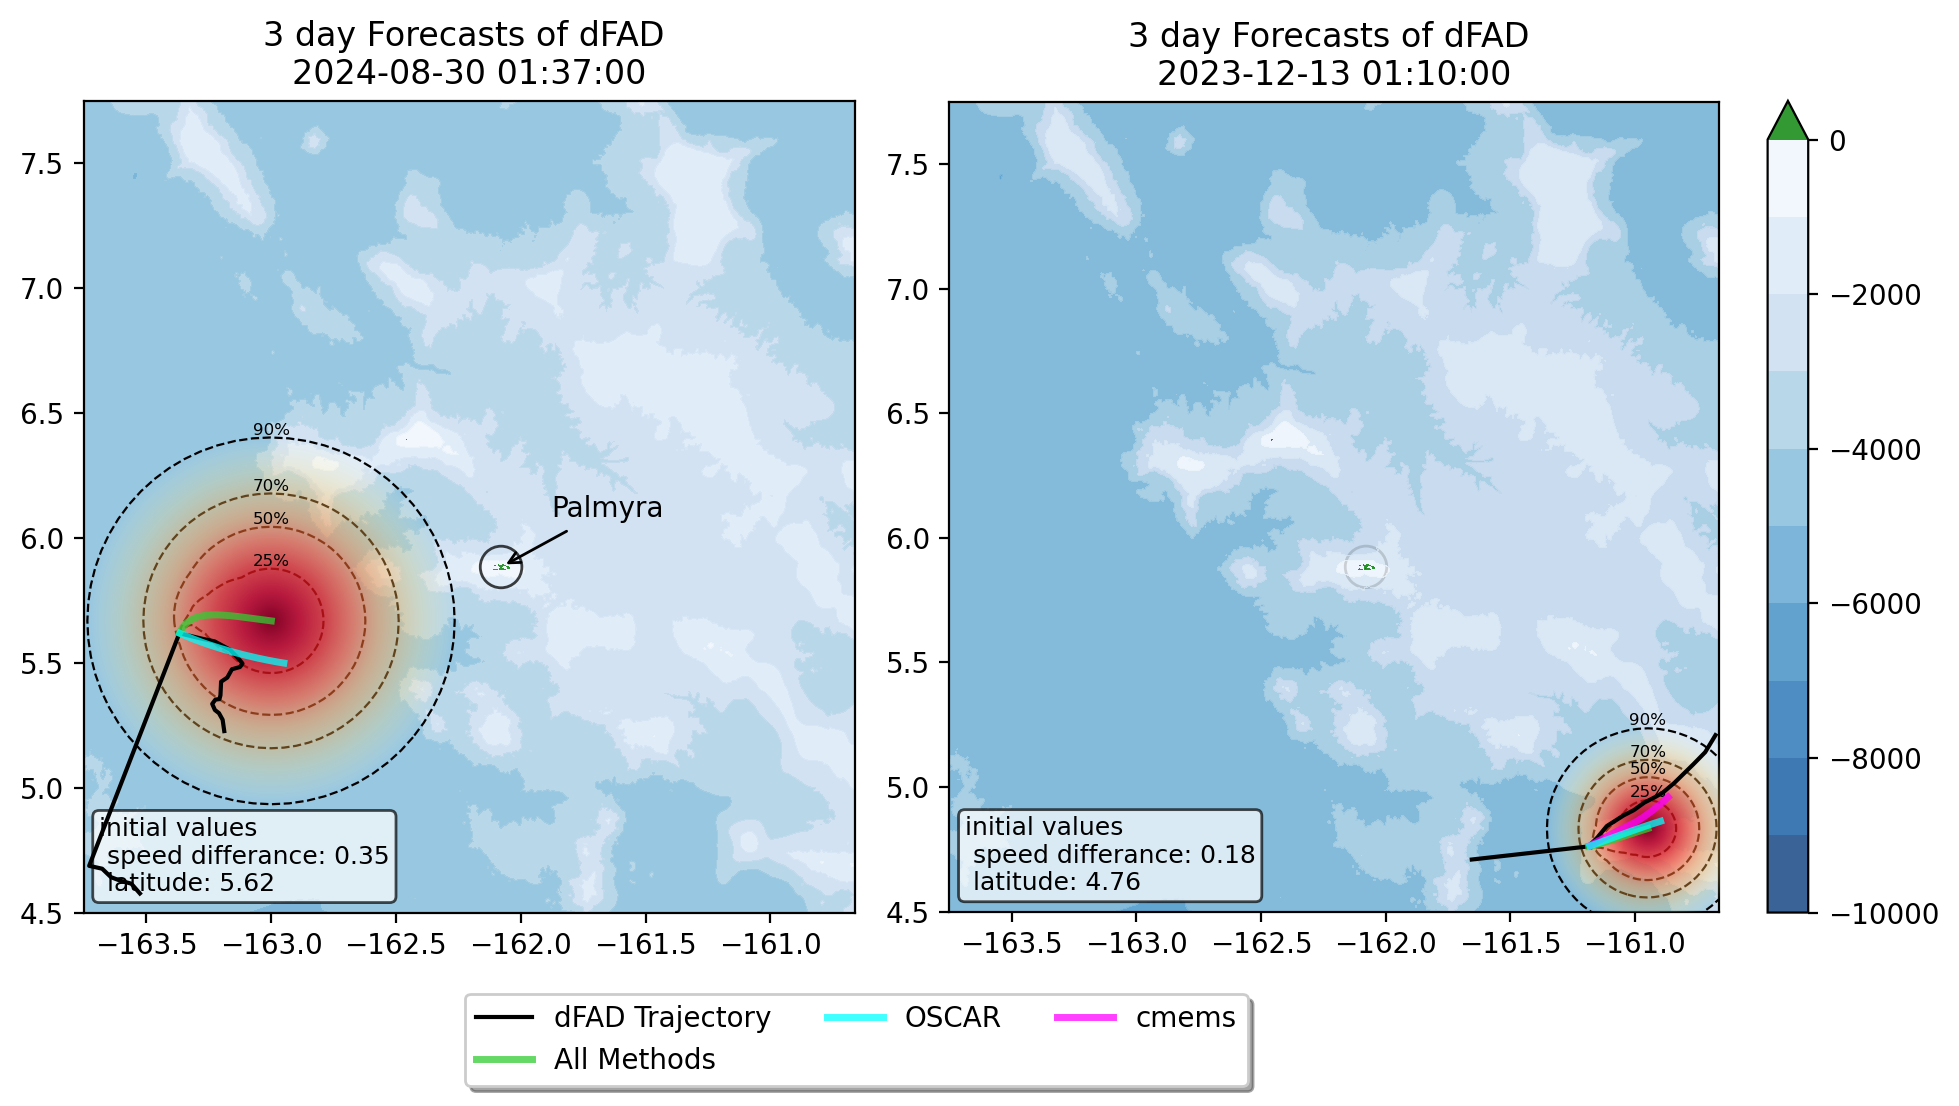

In [ ]:
##plotting one track 
### Give it one dFAD, one point, and all three forcasts 
## Selecting what dFAd and forecast to plot

buoyID = IDs[2000]
print(len(IDs))
sd = 1
def plot_Forecast_from_id(dss:list, ID:int, startday_int: int, fig, ax):
    merged = dss[0]
    merged = merged.sort_values(['BuoyID', 'starttime', 'Time']).reset_index(drop = True)
    IDs = merged.BuoyID.unique()
    sd = startday_int
    buoyID = IDs[ID]

    #getting intial angle and speed to solve error
    Forecast = merged.query(f"BuoyID == @buoyID")
    startdays = Forecast.query(f'leadtime == 0').reset_index(drop = True)
    startday = startdays.at[sd,'Time'].round('min')
    Forecast = Forecast.query(f'starttime == @startday').reset_index(drop= True)
    leadtimes = np.arange(Forecast.leadtime.min(), Forecast.leadtime.max(), 0.5)
    isd = Forecast.initial_speed_dif_mag[0]
    ilat = Forecast.initial_lat[0]
    print(ilat, isd)
    leadtimes = leadtimes[1:]
    ## solving Q
    qs = qdata.copy()
    qs = qs.interp(leadtime = leadtimes, kwargs={"fill_value": "extrapolate"})
    qs['qsolved'] = qs.initial_lat*ilat + qs.initial_speed_dif_mag*isd + qs.Intercept

    fig, ax = plot_Forcasts(buoyID, dFADs, dss, startday = sd, 
                            labels = ["All Methods",'cmems', 'OSCAR'], fig= fig,
                            ax = ax, q=qs, forcastlength= pd.Timedelta(days = 3), 
                            pastTrajectory = pd.Timedelta(days = 7), shaded_cone=True,
                            used_forecast= False) #['merged', 'cmems', 'OSCAR'] 

    fig, ax = Add_bathymetry(fig, ax, cbar = False)
    ax.set_aspect("equal")
    ax = plot_circle_km(ax, radius_km= 0.0833)
    ax.set(xlim = [-163.75, -160.66], ylim = [ 4.5,7.75])
    fig.tight_layout()
    ax.text(0.02, 0.02, f"initial values\n speed differance: {isd:.2f}\n latitude: {ilat:.2f}", transform=ax.transAxes,
            ha="left", va="bottom", fontsize=9, bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.7, edgecolor="black"))
    return fig, ax

i =16
fig, axs = plt.subplots(1,2, figsize = (10,5), dpi = 200)
ax0, ax1 = axs
fig, ax0 = plot_Forecast_from_id([merged, dslist_notinterp[1], dslist_notinterp[2]], 2000+i, 0, fig, ax0)
fig, ax1 = plot_Forecast_from_id([merged, dslist_notinterp[1], dslist_notinterp[2]], 1800+i, 0, fig, ax1)

fig, ax1 = Add_bathymetry(fig, ax1, cbar = True)
# Deduplicate legend labels across all axes
handles, labels = [], []
for ax in fig.axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(3.2/7, 0.01),
        fancybox=True, shadow=True, ncol=3)
lon, lat = plot.Palmyra_obj().xy
pal_lon, pal_lat =lon[0], lat[0]


ax0.annotate( "Palmyra", xy=(pal_lon, pal_lat),xytext=(18, 18),textcoords="offset points",
            arrowprops=dict(arrowstyle="->", lw=1, color="black"),fontsize=10,zorder=8)
#fig.tight_layout()



5.8352 0.02553167291024811
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPolygon
MultiPolygon
Polygon
Polygon
MultiPo

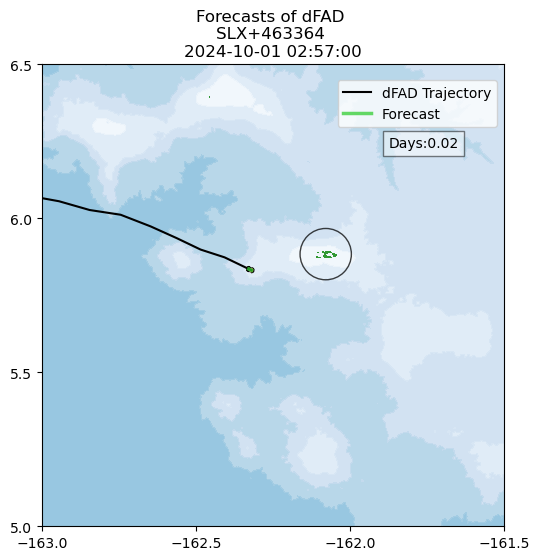

In [151]:
import matplotlib.animation as animation
from matplotlib.ticker import MultipleLocator

merged = merged.sort_values(['BuoyID', 'starttime', 'Time']).reset_index(drop = True)
IDs = merged.BuoyID.unique()
## Selecting what dFAd and forecast to plot

buoyID = IDs[447]
sd = 1
#getting intial angle and speed to solve error
Forecast = merged.query(f"BuoyID == @buoyID")
startdays = Forecast.query(f'leadtime == 0').reset_index(drop = True)
startday = startdays.at[sd,'Time'].round('min')
Forecast = Forecast.query(f'starttime == @startday').reset_index(drop= True)
isd = Forecast.initial_speed_dif_mag[0]
ilat = Forecast.initial_lat[0]
print(ilat, isd)
leadtimes = np.arange(Forecast.leadtime.min(), Forecast.leadtime.max()+0.001, 0.5)
#leadtimes = Forecast.leadtime
leadtimes = leadtimes[1:] ## get rid of zero 
## solving Q
qs = qdata.copy()
qs = qs.interp(leadtime = leadtimes, kwargs={"fill_value": "extrapolate"})
qs['qsolved'] = qs.initial_lat*ilat + qs.initial_speed_dif_mag*isd + qs.Intercept


ds['ledatime'] = pd.to_timedelta(ds.leadtime, 'hours')
## new calc a column of leatimes and error_km

fig, ax = plt.subplots(figsize=(6,6))

def update(hours):
    ax.clear()  # remove previous frame drawings
    # draw forecasts for this many days
    plot_Forcasts(
        buoyID, dFADs, [merged], startday=sd,
        labels=["Forecast"],
        fig=fig, ax=ax,q= qs,
        forcastlength=pd.Timedelta(hours=hours),
        pastTrajectory=pd.Timedelta(days=7), shaded_cone= True
    )
    try:
        ax.legend( loc="upper right", bbox_to_anchor=(1,0.98), bbox_transform=ax.transAxes)
    except Exception:
        pass
    Add_bathymetry(fig, ax, cbar = False)
    ax.set_aspect("equal")
    ax.text(0.75, 0.82, f"Days:{hours/24 :.2f}", bbox=dict(facecolor='white', alpha=0.5), transform=ax.transAxes)
    plot_circle_km(ax, radius_km=0.0833)
    startzoom = 2*24
    endzoom = 3.5*24
    xlim_s = np.array([-163.25+0.25, -161.75+0.25])
    ylim_s = np.array([ 5,6.5])
    xlim_e = np.array([-163.25+0.25, -160.75+0.25])
    ylim_e = np.array([ 4.5,7])
    dxlim = xlim_e - xlim_s
    dylim = ylim_e - ylim_s
    ax.xaxis.set_major_locator(MultipleLocator(0.5))
    ax.yaxis.set_major_locator(MultipleLocator(0.5))
    if hours < 2*24: 
        ax.set(xlim = xlim_s, ylim =ylim_s)
    elif hours < endzoom: 
        ratio = (hours -startzoom)/(endzoom- startzoom)
        ax.set(xlim = xlim_s + dxlim*ratio, ylim = ylim_s + dylim*ratio)
    else:
        ax.set(xlim = xlim_e, ylim = ylim_e)

ani = animation.FuncAnimation(fig, update, frames=leadtimes, interval=100, blit=False)
ani.save(r"..\..\Figures\Animations\Forecast_cone.mp4", writer= 'ffmpeg')

In [ ]:
import matplotlib.animation as animation
## create animation 
IDs = ds3.BuoyID.unique()
buoyID  = IDs[113]
fig, ax = plt.subplots()
def update(days):
    fig, ax = plot_Forcasts(buoyID, dFADs, [ds3], startday = 0, labels = ["Dynamical", "static"], fig= fig, ax = ax, forcastlength= pd.Timedelta(days = days), pastTrajectory = pd.Timedelta(days = 7)) 


ani = animation.FuncAnimation(fig, update, frames =7, interval = 500, blit = False)
ani.save("Forecast_cone.mp4", writer= 'ffmpeg')

In [ ]:
buoyID = "M3i+133729" 
IDs = dsbad.BuoyID.unique()
buoyID = IDs[18] ##Simple one 428427
if False: 
        
    for id in range(len(IDs)):
        buoyID = IDs[id]
        Truedata = True_dFAD_data(dFADs, buoyID)
        fig, ax = plt.subplots()
        days = dsbad.query('BuoyID == @buoyID')['starttime'].unique().shape[0]
        for i in range(days):
            fig, ax = plot_Forcasts(buoyID, dFADs, [dsbad], startday = i,
                                    labels = ["Dynamical", "static"], fig= fig, ax = ax,
                                    pastTrajectory = pd.Timedelta(days = 7), ) 

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys())
        fig, ax = Add_bathymetry(fig, ax)
        ax.set_aspect("equal")
        ax = plot_circle_km(ax, radius_km= 0.0833)
        ax = set_palmyra_lims(ax)
        fig.set_facecolor("#FFFDF6")
        fig.savefig(fr"..\..\Figures\Bad_Forecasts\{buoyID}.jpg")


In [ ]:
dFADs = distance_from_Palymra(dFADs)
dFADs = dFADs.sort_values("distance_km")
dFADs2024 = dFADs[dFADs["MinOfDate"] > pd.to_datetime("2024-1-1")]
dFADs2024 = dFADs2024[dFADs2024["MinOfDate"] < pd.to_datetime("2025-1-1")]
dFADs2024 = dFADs2024.reset_index(drop = True)
ngps = len(Column_to_List(dFADs2024,"TimeStamp"))
print(ngps)

dFADs_5km = dFADs[dFADs.distance_km < 11.12] ##6 nautical miles
print(len(dFADs_5km))
print(dFADs.MinOfDate.min(), dFADs.MaxOfDate.max())
(ngps*(1/111**2)*4/24/365)*24*24
print(len(dFADs))
#print(dFADs.query("BuoyName == 'SLX+480197'"))
dFADs2024.iloc[120]

In [ ]:
fig, ax = plt.subplots()
ax.hist(dFADs['MaxOfDate'], bins = 4*12)
ax.tick_params(axis='x', labelrotation=45)
ax.set_xlabel("start Dates of dFADs ")
ax.set_title("number of new dFADs")